# Name: Sadat Maliha Mashiat

# Email: sadatmaliha703@gmail.com

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv("adult_income.csv", na_values = "?", skipinitialspace = True)

# Q1.

In [ ]:
display(df.shape)

display(df.sample(5))

display(df.isnull().sum())

display(df.duplicated().sum())

df.info()

df.describe()


(48842, 15)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
36332,24,Private,267181,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,35,United-States,<=50K.
12488,30,Private,202450,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,65,United-States,>50K
32465,66,Private,269665,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,0,25,United-States,<=50K
21950,34,Self-emp-inc,209538,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,>50K
30006,43,State-gov,24763,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,1887,45,United-States,>50K


,0
age,0
workclass,2799
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,2809
relationship,0
race,0
sex,0


np.int64(29)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


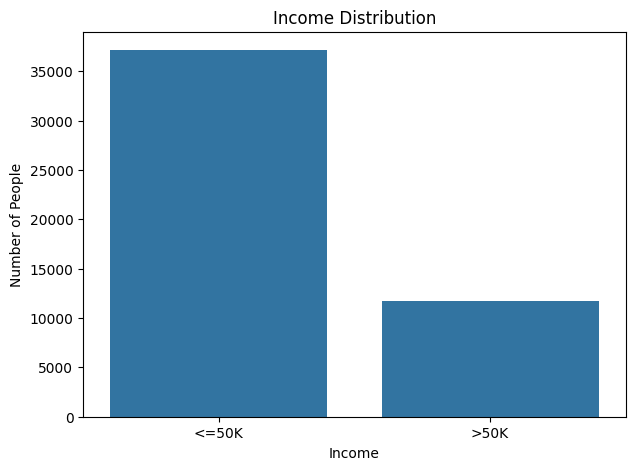

In [ ]:
df["income"] = df["income"].str.strip().str.replace(".", "", regex = False)

plt.figure(figsize = (7, 5))

sns.countplot(
    data = df,
    x = "income",
    order = ["<=50K", ">50K"]
)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of People")

plt.show()

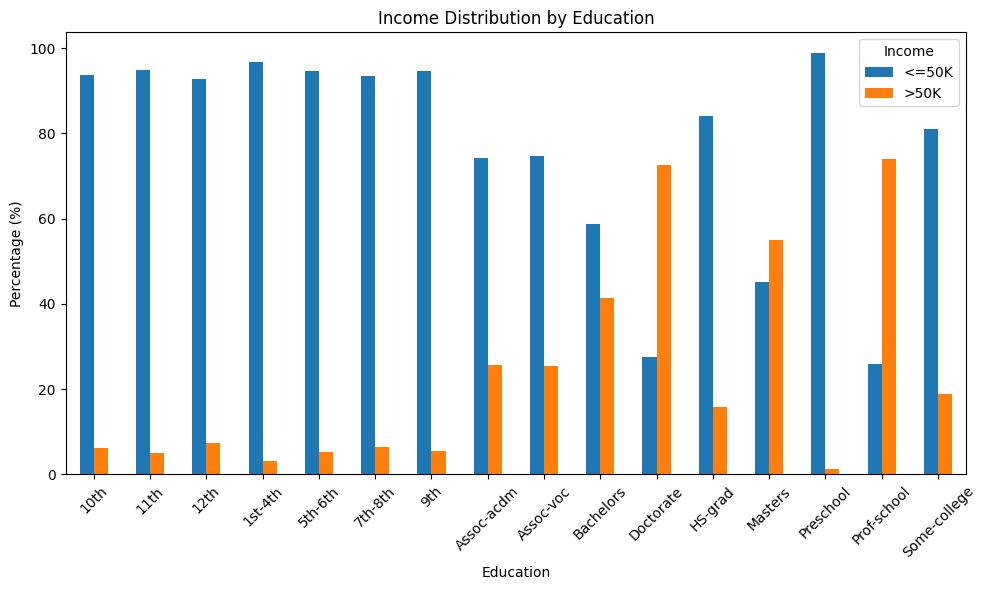

In [ ]:
education_income = pd.crosstab(
    df["education"],
    df["income"],
    normalize = "index"
) * 100

education_income.plot(
    kind = "bar",
    figsize = (10, 6)
)

plt.title("Income Distribution by Education")
plt.xlabel("Education")
plt.ylabel("Percentage (%)")

plt.xticks(rotation = 45)

plt.legend(title = "Income")

plt.tight_layout()
plt.show()

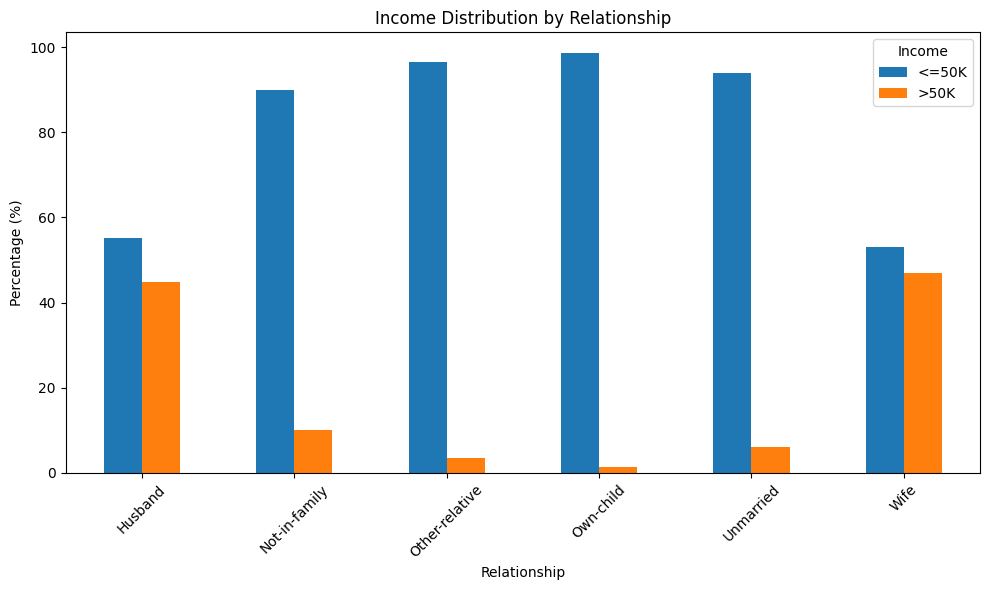

In [ ]:
relationship_income = pd.crosstab(
    df["relationship"],
    df["income"],
    normalize = "index"
) * 100

relationship_income.plot(
    kind = "bar",
    figsize = (10, 6)
)

plt.title("Income Distribution by Relationship")
plt.xlabel("Relationship")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45)

plt.legend(title = "Income")

plt.tight_layout()
plt.show()

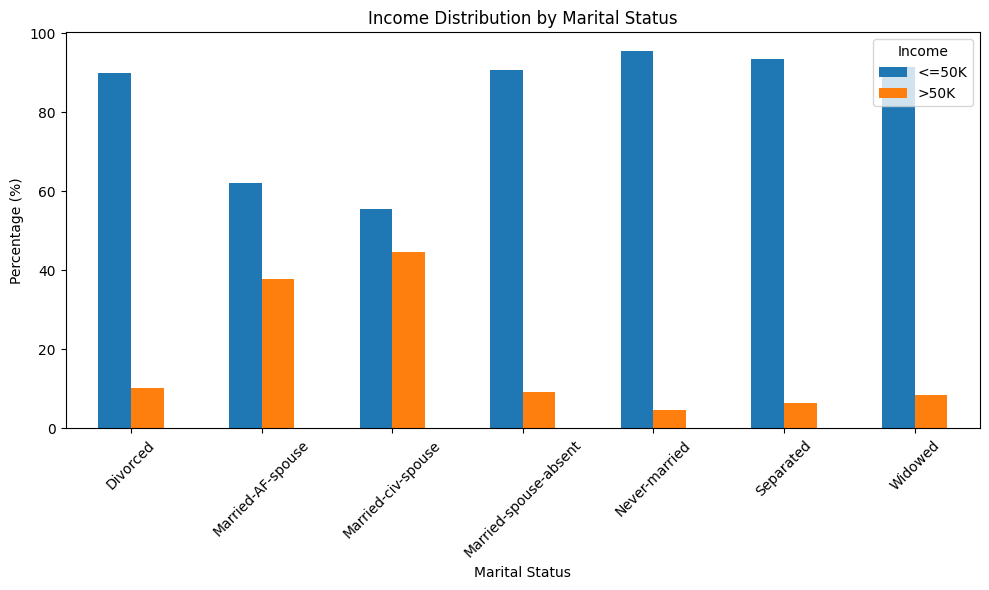

In [ ]:
marital_income = pd.crosstab(
    df["marital-status"],
    df["income"],
    normalize = "index"
) * 100

marital_income.plot(
    kind = "bar",
    figsize = (10, 6)
)

plt.title("Income Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Percentage (%)")

plt.xticks(rotation = 45)

plt.legend(title = "Income")

plt.tight_layout()
plt.show()

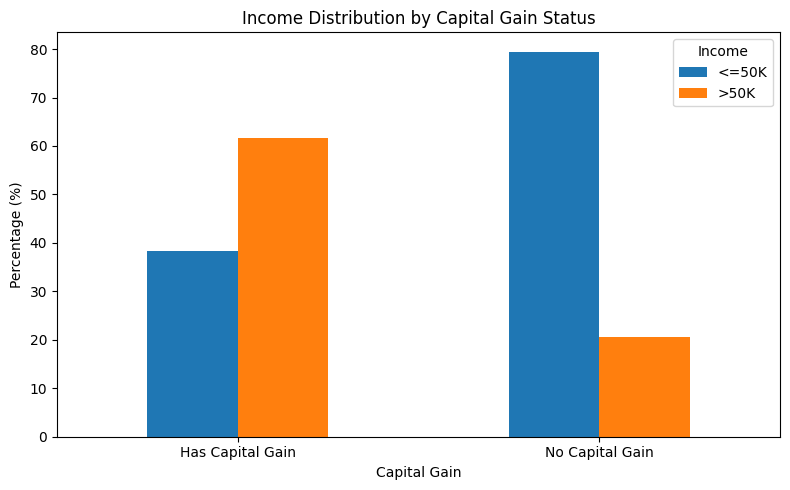

In [ ]:
df["capital_gain_status"] = np.where(
    df["capital-gain"] == 0,
    "No Capital Gain",
    "Has Capital Gain"
)

capital_income = pd.crosstab(
    df["capital_gain_status"],
    df["income"],
    normalize = "index"
) * 100

capital_income.plot(
    kind = "bar",
    figsize = (8, 5)
)

plt.title("Income Distribution by Capital Gain Status")
plt.xlabel("Capital Gain")
plt.ylabel("Percentage (%)")

plt.xticks(rotation = 0)

plt.legend(title = "Income")

plt.tight_layout()
plt.show()

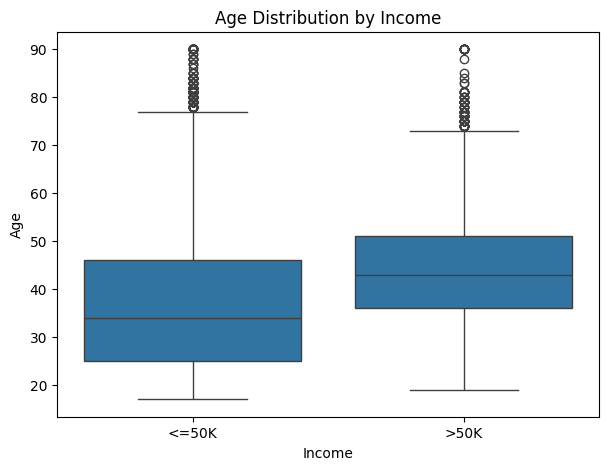

In [ ]:
plt.figure(figsize = (7, 5))

sns.boxplot(
    data = df,
    x = "income",
    y = "age"
)

plt.title("Age Distribution by Income")
plt.xlabel("Income")
plt.ylabel("Age")

plt.show()

In [ ]:

education_stats = pd.crosstab(
    df["education"],
    df["income"],
    normalize = "index"
) * 100

print("\nEducation vs Income (%):")
print(education_stats)



Education vs Income (%):
income            <=50K       >50K
education                         
10th          93.736501   6.263499
11th          94.922737   5.077263
12th          92.694064   7.305936
1st-4th       96.761134   3.238866
5th-6th       94.695481   5.304519
7th-8th       93.507853   6.492147
9th           94.576720   5.423280
Assoc-acdm    74.203623  25.796377
Assoc-voc     74.672489  25.327511
Bachelors     58.716511  41.283489
Doctorate     27.441077  72.558923
HS-grad       84.142169  15.857831
Masters       45.088446  54.911554
Preschool     98.795181   1.204819
Prof-school   26.019185  73.980815
Some-college  81.035117  18.964883


In [ ]:
marital_stats = pd.crosstab(
    df["marital-status"],
    df["income"],
    normalize = "index"
) * 100

print("\nMarital Status vs Income (%):")
print(marital_stats)


Marital Status vs Income (%):
income                     <=50K       >50K
marital-status                             
Divorced               89.883914  10.116086
Married-AF-spouse      62.162162  37.837838
Married-civ-spouse     55.386747  44.613253
Married-spouse-absent  90.764331   9.235669
Never-married          95.452007   4.547993
Separated              93.529412   6.470588
Widowed                91.567852   8.432148


In [ ]:
relationship_stats = pd.crosstab(
    df["relationship"],
    df["income"],
    normalize = "index"
) * 100

print("\nRelationship vs Income (%):")
print(relationship_stats)



Relationship vs Income (%):
income              <=50K       >50K
relationship                        
Husband         55.132887  44.867113
Not-in-family   89.859334  10.140666
Other-relative  96.547145   3.452855
Own-child       98.535813   1.464187
Unmarried       93.970732   6.029268
Wife            53.110253  46.889747


According to my observation - Education, Relationship and Marital-status are the top three features that separate individuals who earn more than 50k from those who earn 50k or less.

Education: In "Income Distribution by Education" barplot we can see the people with higher level of education tend to have higher incomes.

Relationship: The barplot shows that 'Husband' and 'Wife' categaory has the higher incomes while categories such as 'Own-child' and 'Other-relative' have a much lower proportion of high-income individuals.

Marital-Status: From the barplot we can see individuals in the 'Married-civ-spouse' category have a much higher proportion of people earning more than $50K, while 'Never-married' individuals have a much lower proportion of high-income earners.


Rank -
1. Education
2. Relationship
3. Marital-Status

# Q2.

In [ ]:
#splitting numerical and categorical features
numerical_col = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss"]
categorical_col = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country", "income"]

#Pipeline for numerical columns
numerical_transformers = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ]
)

#Pipeline for categorical columns
categorical_transformers = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('encoder', OneHotEncoder(sparse_output = False, handle_unknown = "ignore"))
    ]
)

#Using column transformer for all features
preprocessor = ColumnTransformer(
    transformers = [
        ('numerical', numerical_transformers, numerical_col),
        ('nominal', categorical_transformers, categorical_col)
    ],
    remainder = "passthrough"
)

#Train_test split
X = df.drop("hours-per-week", axis = 1)
Y = df["hours-per-week"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

1. Here, I have used 'median' as simpleimputer strategy because it is less affected by outliers than mean.

2. I used 'StandardScaler' to bring the numerical features into same scale so that features with larger values do not dominate the model.

3. Then i used 'OneHotEncoder' to convert the categorical features into numerical format so that the machine learning model can process them.

# Q3.

In [ ]:
#LinearRegression
LR_pipe = Pipeline(
    steps = [
        ('preprocessor',preprocessor),
        ('model' , LinearRegression())
    ]
)

LR_pipe.fit(X_train, Y_train)
Y_pred = LR_pipe.predict(X_test)

print("Linear Regression:")
print(f"MSE: {round(mean_squared_error(Y_test, Y_pred), 4)}")
print(f"R2: {round(r2_score(Y_test, Y_pred), 4)}")
print(f"RMSE: {round(root_mean_squared_error(Y_test, Y_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(Y_test, Y_pred), 4)}")


#SGD Regression
SGD_pipe = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model' , SGDRegressor())
    ]
)

SGD_pipe.fit(X_train, Y_train)
Y_pred = SGD_pipe.predict(X_test)

print("\nSGD Regression:")
print(f"MSE: {round(mean_squared_error(Y_test, Y_pred), 4)}")
print(f"R2: {round(r2_score(Y_test, Y_pred), 4)}")
print(f"RMSE: {round(root_mean_squared_error(Y_test, Y_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(Y_test, Y_pred), 4)}")


Linear Regression:
MSE: 123.3339
R2: 0.1956
RMSE: 11.1056
MAE: 7.675

SGD Regression:
MSE: 123.2491
R2: 0.1961
RMSE: 11.1018
MAE: 7.6741


SGD Regressor performed slightly better than Linear Regression. It achieved a slightly higher R² score (0.1961 vs 0.1956) and lower MSE (123.2491 vs 123.3339), RMSE (11.1018 vs 11.1056) and MAE (7.6741 vs 7.6750). However, the difference between the two models is very small indicating that their overall performance is almost similar.

# Q4.

In [ ]:
#Train_test split
X = df.drop("income", axis = 1)
Y = df["income"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

#Numerical and Categorical features split
numerical_col = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

categorical_col = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

#Numerical pipeline
numerical_transformers = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ]
)

#Categorical pipeline
categorical_transformers = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('encoder', OneHotEncoder(sparse_output = False, drop = 'first', handle_unknown = 'ignore'))
    ]
)

#Using column transformer for all features
preprocessor = ColumnTransformer(
    transformers = [
        ('numerical', numerical_transformers, numerical_col),
        ('nominal', categorical_transformers, categorical_col)
    ],
    remainder = "drop"
)

#LabelEncoder
LE = LabelEncoder()
LE.fit(Y_train)

Y_train = LE.transform(Y_train)
Y_test = LE.transform(Y_test)


#Model train
LR_model = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(class_weight = 'balanced', max_iter = 1000))
    ]
)

LR_model.fit(X_train, Y_train)
Y_pred = LR_model.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy = {accuracy}")
precision = precision_score(Y_test, Y_pred)
print(f"Precision = {precision}")
recall = recall_score(Y_test, Y_pred)
print(f"Recall = {recall}")








Accuracy = 0.8064284983109837
Precision = 0.5645021645021645
Recall = 0.8366124893071001


# Q5.

In [ ]:
#Train_test split
X = df.drop("income", axis = 1)
Y = df["income"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

#Numerical and categorical column split
numerical_col = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_col = ["workclass", "education", "marital-status", "occupation", "relationship", "race", "sex", "native-country"]

#Numerical pipeline
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])

#Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown = "ignore"))
])

#Using pipeline for all features
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_col),
    ("categorical", categorical_pipeline, categorical_col)
])

#KNN model pipeline
knn_model = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier())
    ]
)

#LabelEncoder
LE = LabelEncoder()
LE.fit(Y_train)

Y_train = LE.transform(Y_train)
Y_test = LE.transform(Y_test)

#GridSearchCV
grid = {
    "knn__n_neighbors" : [3, 5, 7],
    "knn__weights" :['uniform', 'distance'],
    "knn__p" : [1, 2]
}


grid_search = GridSearchCV(
    estimator = knn_model,
    param_grid = grid,
    cv = 3,
    scoring = "accuracy",
    n_jobs = -1

)

grid_search.fit(X_train, Y_train)
model = grid_search.best_estimator_
Y_pred= model.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Best Parameters: {'knn__n_neighbors': 7, 'knn__p': 2, 'knn__weights': 'uniform'}
Accuracy: 0.8371378851468932
Precision: 0.6789650215620507
Recall: 0.6060735671514115


The tuned KNN model performed better overall than the default Logistic Regression model because it achieved higher Accuracy and Precision. However, Logistic Regression achieved a significantly higher Recall, meaning it was better at identifying individuals who earn more than $50K.